<a href="https://colab.research.google.com/github/ibnuzzi/PCVK_Ganjil_26/blob/main/Week6_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1: Mount Google Drive & Import Library**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

**Langkah 2: Membuat Fungsi Konvolusi Manual (Tanpa Library)**

In [3]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Membalikkan kernel (rotasi 180 derajat) untuk operasi konvolusi
    kernel = np.flipud(np.fliplr(kernel))

    h_img, w_img = image.shape
    h_kern, w_kern = kernel.shape

    # Menambahkan Zero Padding jika padding > 0
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_image = image.copy()

    # Menghitung dimensi citra keluaran
    out_h = int((h_img - h_kern + 2 * padding) / stride) + 1
    out_w = int((w_img - w_kern + 2 * padding) / stride) + 1

    output = np.zeros((out_h, out_w))

    # Menggeser kernel pada citra (sliding window)
    for y in range(0, out_h):
        for x in range(0, out_w):
            region = padded_image[y*stride : y*stride + h_kern, x*stride : x*stride + w_kern]
            output[y, x] = np.sum(region * kernel)

    # Mengontrol nilai intensitas piksel agar berada di rentang 0-255
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

**Langkah 3: Load Citra dan Ubah ke Grayscale**

In [4]:
img_path = '/content/drive/MyDrive/PCVK/mandrill.tiff'
img = cv.imread(img_path)

# Mengubah citra BGR ke Grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

**Langkah 4: Definisi Kernel & Penerapan Filter**

In [5]:
# 1. Average Filter (Low Pass Filter)
kernel_avg = np.ones((3, 3), dtype=np.float32) / 9.0

# 2. High Pass Filter
kernel_hpf = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
])

# 3. Sharpen Filter
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# 4. Emboss Filter
kernel_emboss = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
])

# 5. Left Sobel Edge Detection
kernel_left_sobel = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
])

# 6. Canny Edge Detection (Laplacian / High Pass Edge Detection)
kernel_canny = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# 7. 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

**Langkah 5: Mengaplikasikan Konvolusi dan Menampilkan Hasil**

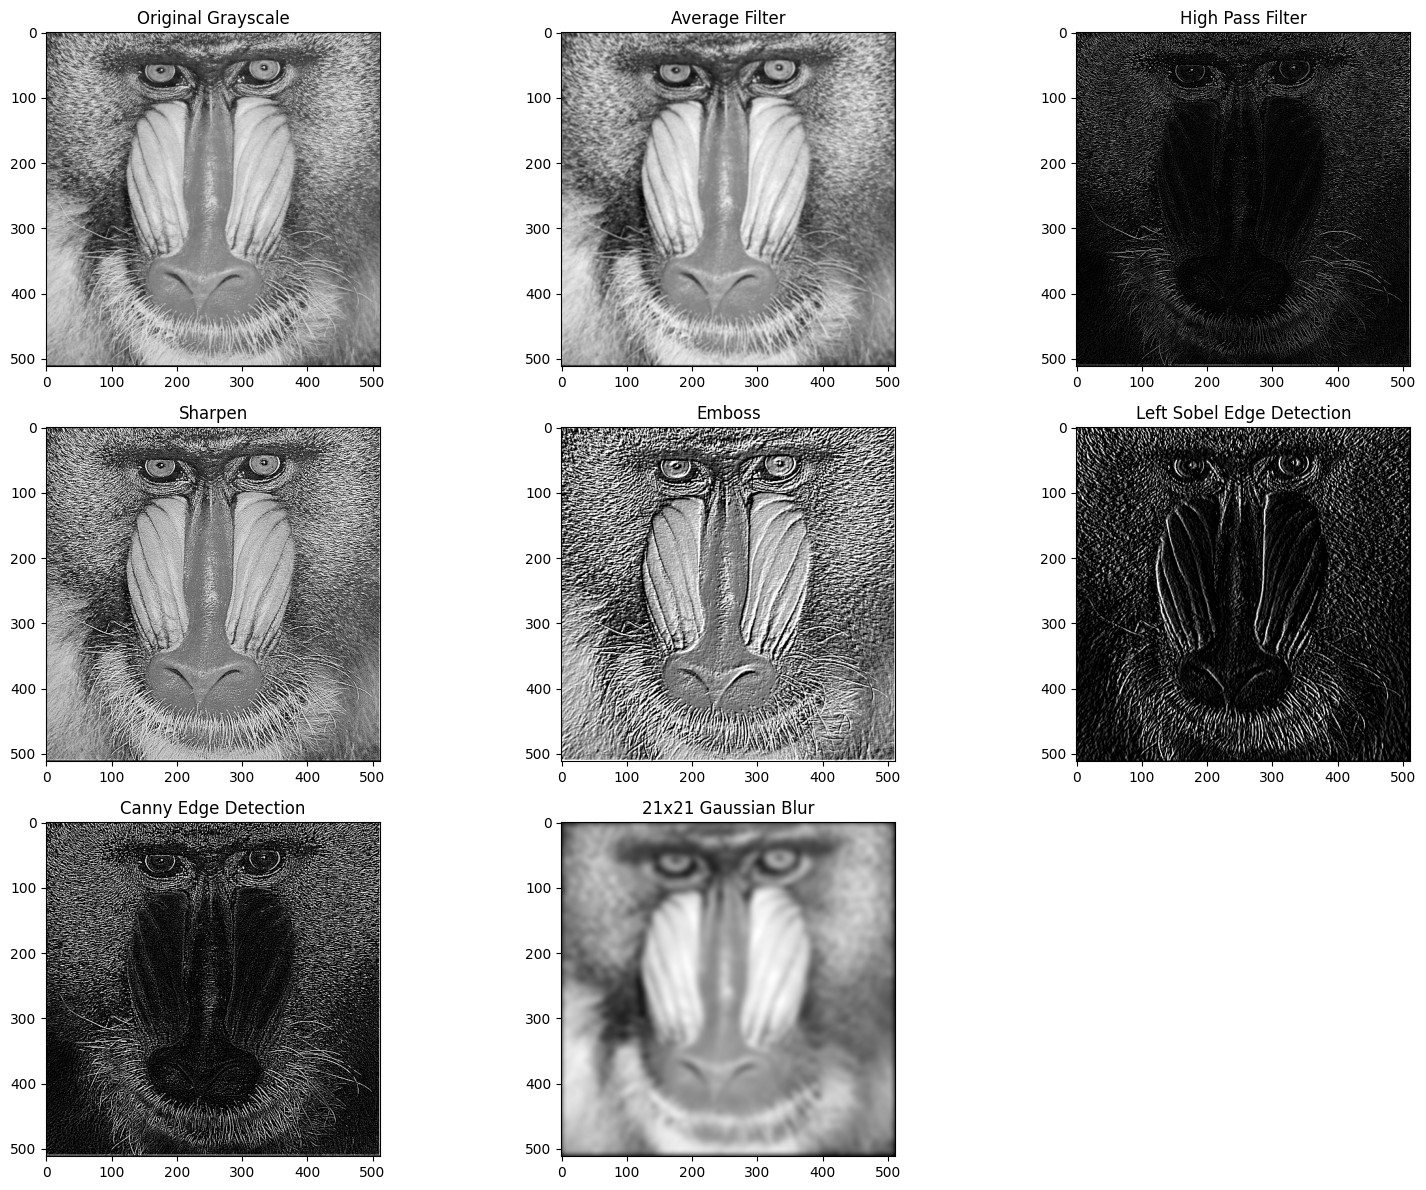

In [6]:
# Proses konvolusi masing-masing filter
res_avg        = convolution2d(img_gray, kernel_avg, stride=1, padding=1)
res_hpf        = convolution2d(img_gray, kernel_hpf, stride=1, padding=1)
res_sharpen    = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss     = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_sobel      = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny      = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
res_gaussian   = convolution2d(img_gray, kernel_gaussian, stride=1, padding=10)

# Menampilkan hasil visualisasi
results = [
    ("Original Grayscale", img_gray),
    ("Average Filter", res_avg),
    ("High Pass Filter", res_hpf),
    ("Sharpen", res_sharpen),
    ("Emboss", res_emboss),
    ("Left Sobel Edge Detection", res_sobel),
    ("Canny Edge Detection", res_canny),
    ("21x21 Gaussian Blur", res_gaussian)
]

plt.figure(figsize=(16, 12))
for i, (title, res_img) in enumerate(results):
    plt.subplot(3, 3, i + 1)
    plt.imshow(res_img, cmap='gray')
    plt.title(title)
    plt.axis('on')

plt.tight_layout()
plt.show()

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # Grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # Color (BGR to RGB)
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

**Percobaan 1: Filter Gaussian, Sharpen, dan Canny (OpenCV Library)**

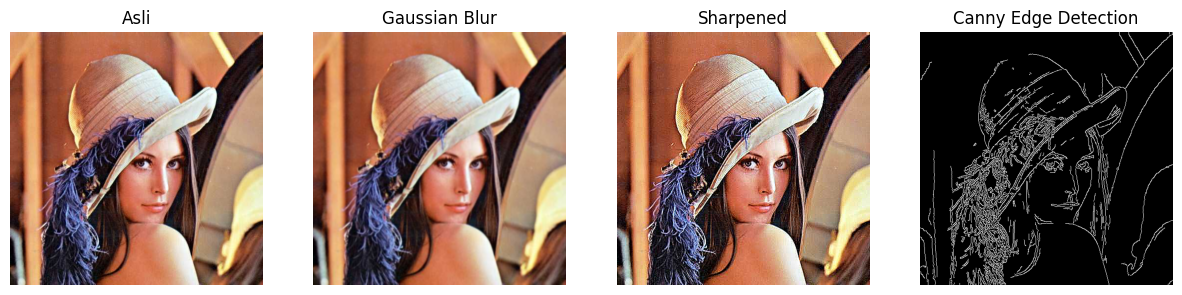

In [8]:
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

**Percobaan 2: Bilateral Filtering & Edge Preserving Filter**

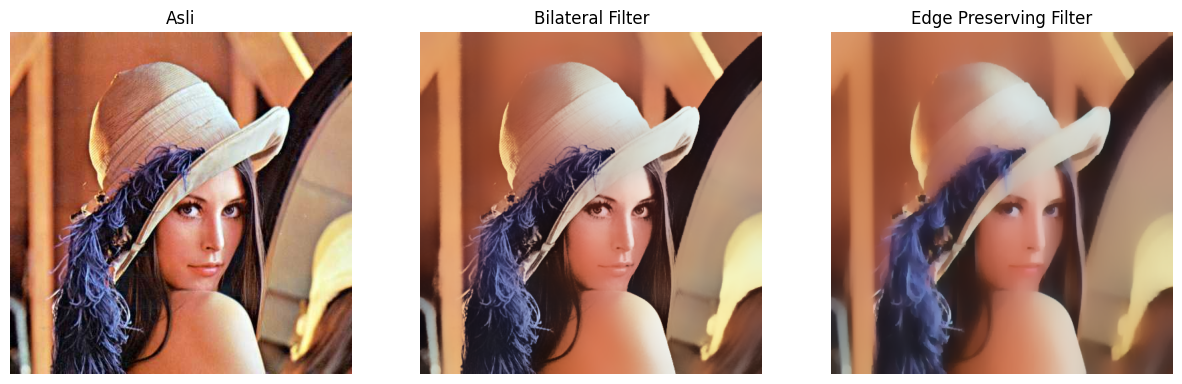

In [9]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

**Percobaan 3: Filter Feature Map pada CNN (PyTorch)**

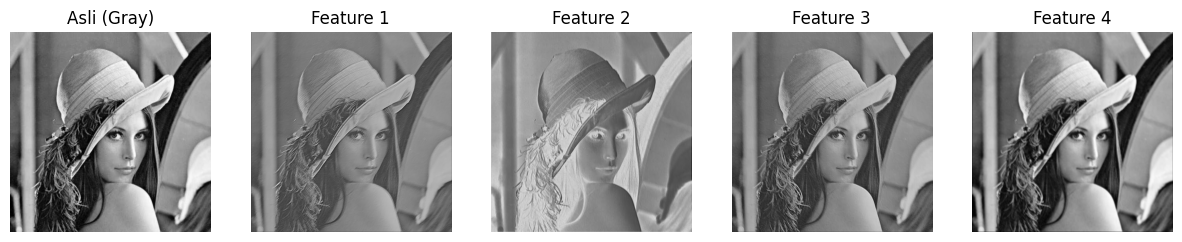

In [10]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**Jawaban & Kesimpulan Percobaan 3**

- **Hasil Pengamatan:** Setiap kali kode dijalankan tanpa seed acak (random seed), bobot (weights) dari layer nn.Conv2d diinisialisasi secara acak oleh PyTorch.
- **Kesimpulan**: Ekstraksi fitur (feature map) pada layer pertama CNN bertindak sebagai sekumpulan filter independen. Setiap kernel mengekstraksi informasi struktur visual yang berbeda, seperti deteksi garis vertikal/horizontal, area perubahan warna, maupun deteksi tepi.

**Percobaan 4: Beauty Filter & Old/Vintage Filter**

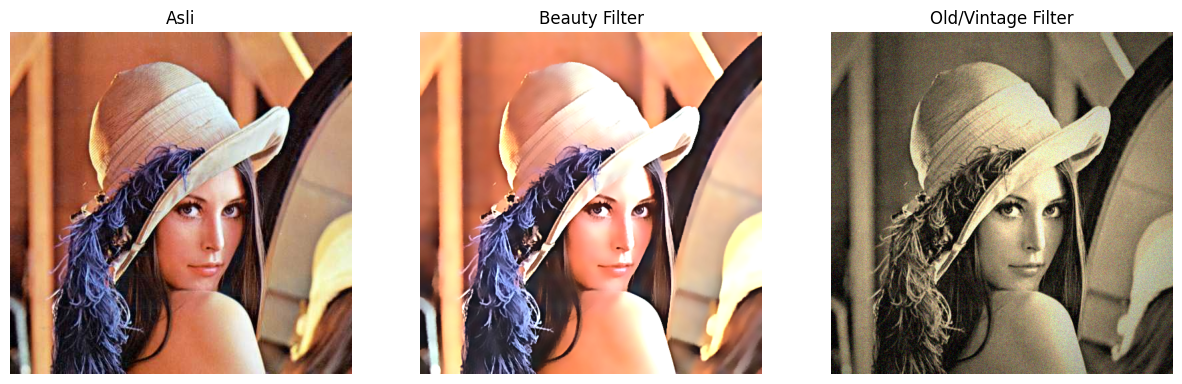

In [11]:
# 1. Beauty Filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
sepia_kernel = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

**Percobaan 5: Filter Anime / Cartoon**

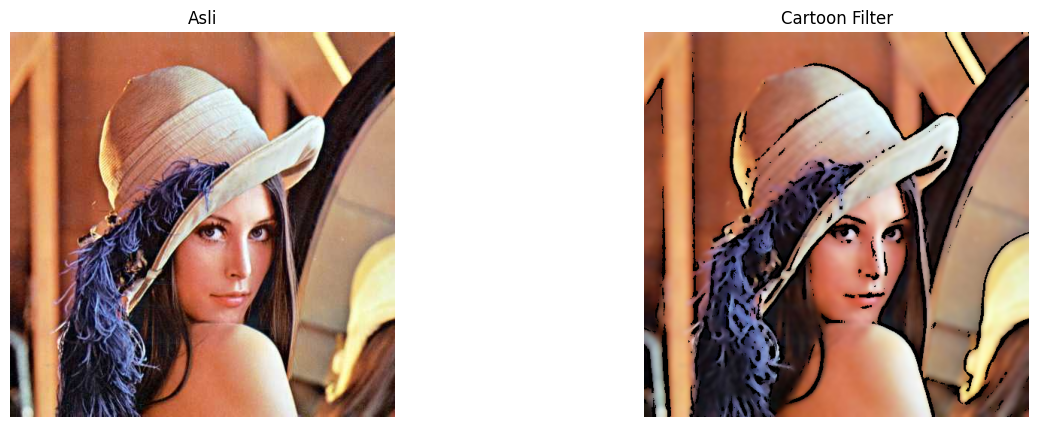

In [12]:
# Step 1: Edge Detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (Cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

**Percobaan 6: Night Filter**

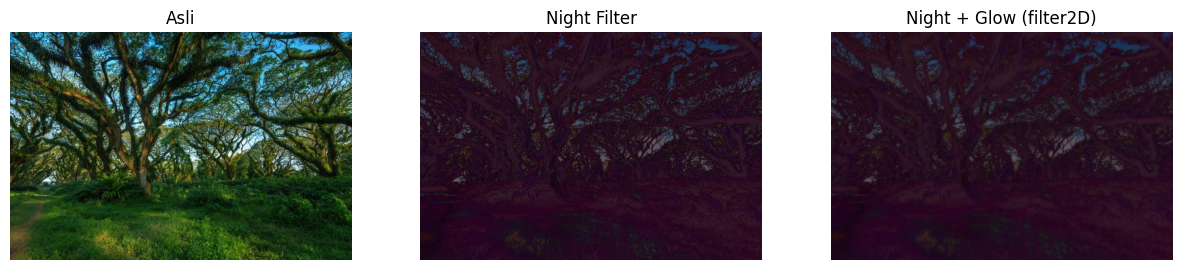

In [14]:
img_djawatan = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")

# Step 1: Gelapkan (kontras turun, brightness negatif)
night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru (BGR)
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_djawatan, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

**Percobaan 7: Filter Suasana Pagi dan Kabut**

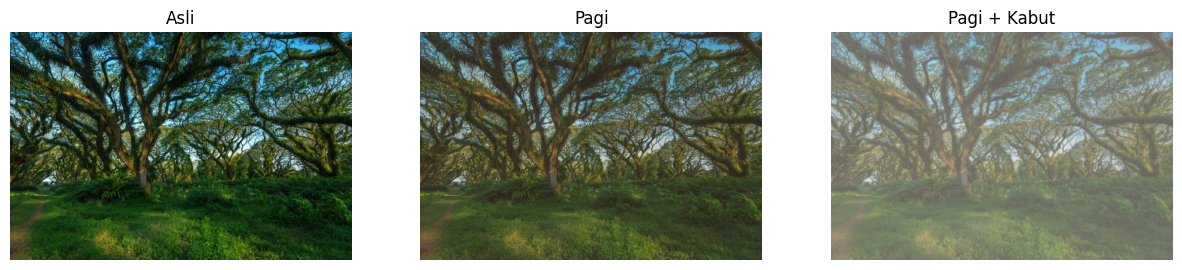

In [15]:
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img_djawatan, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye BGR)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_djawatan, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

**1. Tugas Analisis: Perbandingan Mean Filter vs. Median Filter pada Noise "Salt and Pepper"**

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Fungsi untuk menambahkan Salt and Pepper Noise
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)

    # Tambah Salt (Bintik Putih = 255)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Tambah Pepper (Bintik Hitam = 0)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0

    return noisy_image

# Load Citra Grayscale
img = cv.imread('/content/drive/MyDrive/Kuliah/PCVK Genap 2023/Images/lena.jpg', cv.IMREAD_GRAYSCALE)

# a. Tambahkan noise Salt & Pepper
noisy_img = add_salt_and_pepper_noise(img, salt_prob=0.05, pepper_prob=0.05)

# b. Terapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(noisy_img, (3, 3))
median_filtered = cv.medianBlur(noisy_img, 3)

# Tampilkan Hasil Perbandingan
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Salt & Pepper Noise')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filter (3x3)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filter (3x3)')
plt.axis('off')

plt.show()

**c. Analisis Hasil Visual**
*   **Mengapa Mean Filter kurang efektif?**
Mean Filter bekerja dengan menghitung rata-rata aritmatika intensitas semua piksel di dalam jendela kernel $3 \times 3$. Karena noise salt ($255$) dan pepper ($0$) memiliki nilai ekstrim, nilai ekstrim tersebut ikut dirata-ratakan ke piksel tetangganya. Akibatnya, noise tidak hilang melainkan menyebar menjadi bercak abu-abu yang membuat citra menjadi buram (blurry).
*   **Mengapa Median Filter jauh lebih bersih?**
Median Filter mengurutkan nilai intensitas piksel di dalam jendela kernel $3 \times 3$ lalu mengambil nilai tengah (median). Karena noise salt and pepper bernilai sangat ekstrim (paling tinggi $255$ atau paling rendah $0$) dan populasinya sedikit, nilai noise ini selalu berada di ujung terluar urutan. Nilai median yang terpilih hampir dipastikan adalah nilai piksel tetangga yang normal. Oleh karena itu, Median Filter dapat menghapus bintik noise secara sempurna tanpa mengaburkan detail tepi objek.

**2. Tugas Evaluasi: Pemilihan Ukuran Kernel Terbaik untuk Sharpening**

In [ ]:
# Buat citra sedikit buram terlebih dahulu
blurry_img = cv.GaussianBlur(img, (5, 5), 0)

# a. Buat Sharpening Kernel ukuran 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

kernel_sharpen_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, 25, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1]
])

# b. Terapkan pada citra buram
sharpened_3x3 = cv.filter2D(blurry_img, -1, kernel_sharpen_3x3)
sharpened_5x5 = cv.filter2D(blurry_img, -1, kernel_sharpen_5x5)

# Tampilkan Hasil
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blurry_img, cmap='gray')
plt.title('Citra Buram (Input)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpened_3x3, cmap='gray')
plt.title('Sharpening Kernel 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharpened_5x5, cmap='gray')
plt.title('Sharpening Kernel 5x5')
plt.axis('off')

plt.show()

**c. Evaluasi & Rekomendasi Kernel Optimal**

**Aspek Kejelasan Tepi vs. Kadar Noise/Distorsi:**
- **Kernel $3 \times 3$:** Menghasilkan peningkatan ketajaman tepi yang pas dan alami. Kontras pada batas objek meningkat tanpa memicu pembentukan noise tinggi atau efek halo (ringing artifact).
- **Kernel $5 \times 5$:** Menajamkan citra secara sangat agresif. Tepi tampak terdistorsi karena kontras yang terlalu tinggi (over-sharpened), serta mengamplifikasi noise pada area datar (kulit/background) sehingga muncul tekstur kasar yang tidak diinginkan.

**Kernel Paling Optimal:**

**Kernel $3 \times 3$** adalah pilihan yang paling optimal untuk penggunaan sehari-hari karena menjaga keseimbangan terbaik antara kejelasan tepi (sharpness) dan pencegahan timbulnya distorsi noise.

**3. Tugas Kreasi: Filter Kartun Sederhana**

In [ ]:
# a. Buat fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9,
        C=9
    )

    # Ubah edges ke 3 channel jika image bertipe BGR
    if len(image.shape) == 3:
        edges = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan (kombinasi) menggunakan operasi logika bitwise_and
    cartoon_image = cv.bitwise_and(color, edges)

    return cartoon_image

# Load citra berwarna
img_color = cv.imread('/content/drive/MyDrive/Kuliah/PCVK Genap 2023/Images/lena.jpg')

# Panggil fungsi kartun
img_cartoon = kartun(img_color)

# b. Tampilkan hasil citra asli dan citra efek kartun bersebelahan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_cartoon, cv.COLOR_BGR2RGB))
plt.title('Efek Kartun Sederhana')
plt.axis('off')

plt.show()